# Introduction
Welcome to Lab 2, in this lab we will take our first steps into applying ML to satellite data, using landcover analysis as our primary goal.

As covered in Lecture 2, landcover classification is the quintessential remote sensing task in the civil sector. The LandSat programme (Lecture 3) was originally developed in large part to enable the USA to monitor landcover more easily for a range of agricultral, govermental and finacial problemsets. It remains a primary task for governments and companies around the world.

This is a pixel-wise ML task. We will apply two methods, both of which are available in GEE as ready-to-go algorithms. In this instance we are happy to go with built-in as it allows us to become familiar with an end-to-end GEE ML workflow without getting bogged down in technical detail. No need to re-invent the wheel unless you are going to the [moon](https://www.nasa.gov/feature/ames/artemis-moon-rover-s-wheels-are-ready-to-roll/).

Remember that this is a set of exercises and tutorials that escalate in difficulty. Always show your working and do not neccesarily expect to get full marks on everything.

Use the resources available to you outside of this material. I expect you to search for concepts or terms you do not understand and to look at the documentation of the code packages that we are using in the first instance of getting stuck. But do then of course ask us for help in the lab and on EdDiscussion.
_______________________________________________________________________________

# Set up

In [27]:
# Install libs if needed, note the --quiet option means a lot less annoying info than as Lab 1 when we did the same!
!pip install geemap --quiet

In [28]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='geog761-lrei069') #<- Remember to change this to your own project's name!

In [30]:
# Import other libs
import geemap
import geopandas as gpd
import pandas as pd

# Define Area of Interest (AOI)

In [32]:
# Define area of interest (e.g., Wellington, NZ)
aoi = ee.Geometry.Rectangle([174.6, -41.4, 174.9, -41.2])
Map = geemap.Map(center=[-41.3, 174.75], zoom=10)
Map.addLayer(aoi, {}, 'AOI')

# Visualize on the map to check got it right... (always a good idea)
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

# Load and Cloud Mask Imagery from Earth Engine

In [34]:
# Set up your filter Sentinel-2 imagery
# A function that masks clouds in your S2 images via QA band
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
           qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask).divide(10000).select(['B2', 'B3', 'B4', 'B8'])

# Now build the clean collection with selected bands
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2021-01-01', '2021-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .median() #<- think about this step and what it is doing to your image when you build your single composite from the image collection
      .clip(aoi))

(1) What other mathematical [compositing](https://developers.google.com/earth-engine/guides/ic_composite_mosaic) approaches could you take when building your single image from the filtered image collection you create in the cell above? Hint: you currently are doing a 'median-composite'. (3 pts)

In [35]:
# Set up the visualisation and then once again check it has worked, stacking layers in a sensible order
Map = geemap.Map(center=[-41.3, 174.75], zoom=11) #<- reset the map object to clear out other layers from earlier cells
Map.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 RGB')
Map.addLayer(aoi, {'color': 'red'}, 'AOI')
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

________________________________________________________________________________

# Training data

We are going to train our data using the European Space Agency (ESA) world landcover map. Given that this is derived from satellite data our logic is at risk of becoming a little circular here. But as a training exercise it is a good way to have easy to access training data of the right size and type to apply to our image.

There are a wide range of landcover datasets in the GEE catalogue that you can use for this purpose:
*   https://developers.google.com/earth-engine/datasets/tags/landuse-landcover

First, we will load in the landcover map we will use to create our training dataset (https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v100):



Next we need to use our landcover map to [sample](https://developers.google.com/earth-engine/apidocs/ee-image-sample) the Sentinel 2 image, associating each pixel of a given landcover with the spectral band values 'beneath' it.

In [36]:
# Define valid WorldCover classes (10 to 100, spaced by 10)
valid_classes = ee.List.sequence(10, 100, 10)

# Need to change this to sequential list to avoid the algs thiniing there are 99 classes rather than 9
remap_to = ee.List.sequence(1, 10)

# Load landcover map
landcover = ee.Image('ESA/WorldCover/v100/2020').select('Map').clip(aoi)

# Remap labels: create a new band with remapped values (10 → 1, ..., 100 → 10)
landcover_remapped = landcover.remap(valid_classes, remap_to).rename('Map_remapped')

(2) What year of data was this landcover map (accessed in the cell above) created on? (1 pt)

In [37]:
# Add landcover original and remapped as bands to Sentinel-2 image
training_data = s2.addBands(landcover_remapped)

Let's inspect the resulting training dataset and make sure that you understand what you have built here.

We are going to:
- Print the first few rows (client-side).
- Check the number of samples per class (server-side with reduceColumns).

This may take a little time to run as we request data both client and server side.

In [38]:
# Sample the image
bands = ['B2', 'B3', 'B4', 'B8']
sample = training_data.select(bands + ['Map_remapped']).sample(
    region=aoi,
    scale=10,
    numPixels=5000,
    seed=2,
    geometries=True)

# Print first 10 sample points (client-side)
first_10 = sample.limit(10).getInfo()

print('\nFirst 10 training samples:')
for i, feature in enumerate(first_10['features']):
    props = feature['properties']
    print(f"Sample {i+1}: Class={props['Map_remapped']}, B2={props['B2']}, B3={props['B3']}, B4={props['B4']}, B8={props['B8']}")

# Count number of samples per class (server-side)
class_counts = sample.reduceColumns(
    reducer=ee.Reducer.frequencyHistogram(),
    selectors=['Map_remapped'])

print('\nClass distribution in sample:')
print(class_counts.getInfo())



First 10 training samples:
Sample 1: Class=8, B2=0.026799999177455902, B3=0.026499999687075615, B4=0.005799999926239252, B8=0.002899999963119626
Sample 2: Class=8, B2=0.039400000125169754, B3=0.028750000521540642, B4=0.0077333333902060986, B8=0.004800000227987766
Sample 3: Class=1, B2=0.01510000042617321, B3=0.03849999979138374, B4=0.02287999913096428, B8=0.23090000450611115
Sample 4: Class=8, B2=0.04749999940395355, B3=0.03200000151991844, B4=0.007666666526347399, B8=0.004550000187009573
Sample 5: Class=1, B2=0.011644444428384304, B3=0.02458333410322666, B4=0.018553845584392548, B8=0.2840000092983246
Sample 6: Class=5, B2=0.10279999673366547, B3=0.09380000084638596, B4=0.09399999678134918, B8=0.12139999866485596
Sample 7: Class=1, B2=0.025599999353289604, B3=0.049800001084804535, B4=0.03869999945163727, B8=0.3156000077724457
Sample 8: Class=8, B2=0.04417499899864197, B3=0.032229166477918625, B4=0.008299999870359898, B8=0.003800000064074993
Sample 9: Class=8, B2=0.03579999879002571, B

(3) What type of landcover is being sampled in sample number 2 of the dataset? Make sure your random seed is set to 2 in the sampling code so that you get the same answer as me. (1 pt)

In [39]:
# Q3

worldcover_names = {
    1: "Tree cover",
    2: "Shrubland",
    3: "Grassland",
    4: "Cropland",
    5: "Built-up",
    6: "Bare / sparse vegetation",
    7: "Snow and ice",
    8: "Permanent water bodies",
    9: "Herbaceous wetland",
    10: "Moss and lichen",
}

second_sample = ee.Feature(sample.toList(2).get(1))
second_class = int(second_sample.get("Map_remapped").getInfo())

print("Sample 2 remapped class:", second_class)
print("Sample 2 land-cover type:", worldcover_names[second_class])

Sample 2 remapped class: 8
Sample 2 land-cover type: Permanent water bodies


We are now ready to start machine learning on classifying the landcover of Wellington!
________________________________________________________________________________

# Random Forest Classification for Landcover
Let us do machine learning properly and first apply a 70/20/10 split that allows us to produce some accuracy statistics.

In [40]:
# Add random column
sample = sample.randomColumn('random')

# Split
train = sample.filter(ee.Filter.lt('random', 0.7))
valid = sample.filter(ee.Filter.And(ee.Filter.gte('random', 0.7), ee.Filter.lt('random', 0.9)))
test = sample.filter(ee.Filter.gte('random', 0.9))

Our next task is to set up a classifier object, followed by applying it to the image using the .classify operator. This operator hides a LOT of behind the scenes plumbing from Google.

We use the [GEE Random Forest](https://developers.google.com/earth-engine/apidocs/ee-classifier-smilerandomforest) model that they have pre-built for us. Specifying the number of trees to use is the only variable we must set. Othe variables are available, read the docs!

In [41]:
# Train the RF model
classifier = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
    features=train,
    classProperty='Map_remapped',
    inputProperties=bands)

With the model trained, we just apply it simply using the '.classify' operator.

In [42]:
# Classify image
classified = s2.select(bands).classify(classifier)

Let's visualize what we have just made!

In [45]:
# Classified image viz, fresh set up again to make sure we have exactly what we want displayed.
Map = geemap.Map()
Map.centerObject(aoi, 10)
Map.addLayer(classified.randomVisualizer(), {}, 'Classified')
Map.addLayer(landcover_remapped.randomVisualizer(), {} ,'ESA Landcover')
Map

Map(center=[-41.300046246343555, 174.75000000000097], controls=(WidgetControl(options=['position', 'transparen…

(4) Look at the ESA landcover map and our resulting random forest classified Sentinel 2 image map. How are they different and what might be some causes of this difference? (5 pts)

Finally, we will apply our test data split and produce the [summary statistics](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall) that we need to make smart choices about our training approach.

In [44]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd


# Validate
validated = valid.classify(classifier, 'predicted')

# Function to export data for confusion matrix
def fc_to_lists(fc, classProp, predProp):
    values = fc.aggregate_array(classProp).getInfo()
    preds = fc.aggregate_array(predProp).getInfo()
    return values, preds

# Get predicted vs actual from validation set
y_true, y_pred = fc_to_lists(validated, 'Map_remapped', 'predicted')

# Labels for original classes
label_map = {i + 1: valid_classes.get(i).getInfo() for i in range(10)}
label_names = [label_map[i + 1] for i in range(10)]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(1, 11)))
report = classification_report(y_true, y_pred, labels=list(range(1, 11)), target_names=[str(l) for l in label_names])

# Pretty-print
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       229        0       20        0        5        0        0   
Actual 20         1        0        1        0        0        0        0   
Actual 30        38        0      117        0        3        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         4        0        8        0       28        3        0   
Actual 60         1        0        1        0        4        0        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        2        0        0   
Actual 90         0        0        2        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

(5) Exercise: modify the code so that you feed into your random forest classifier that has been trained on 2020 data, on other years of Sentinel 2 data than 2020. Produce a publication quality figure that presents the following:
*   Landcover maps of Wellington for 2018, 2022 and 2024
*   The Test accuracy averages of the RF classifier for 2020.
*   Include a sentence in your figure caption that explains why you cannot state the accuracy of the classifier for years other than 2020.

(15 pts)
_______________________________________________________________________________


In [49]:
# Q5

# Function to cloud-mask Sentinel-2 using the SCL band.
def mask_s2_q5(image):
    scl = image.select('SCL')

    clear = (
        scl.neq(3)      # cloud shadow
        .And(scl.neq(8))   # medium probability cloud
        .And(scl.neq(9))   # high probability cloud
        .And(scl.neq(10))  # cirrus
        .And(scl.neq(11))  # snow / ice
    )

    return (
        image.updateMask(clear)
        .divide(10000)
        .select(bands)
    )


# Function to create a yearly Sentinel-2 median composite
def make_year_composite(year):
    return (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(f'{year}-01-01', f'{year + 1}-01-01')
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
        .map(mask_s2_q5)
        .median()
        .clip(aoi)
    )


# Make the three requested yearly composites
s2_2018 = make_year_composite(2018)
s2_2022 = make_year_composite(2022)
s2_2024 = make_year_composite(2024)


# Apply the Random Forest classifier trained on 2020 data
classified_2018 = s2_2018.select(bands).classify(classifier)
classified_2022 = s2_2022.select(bands).classify(classifier)
classified_2024 = s2_2024.select(bands).classify(classifier)

In [50]:
# Check maps

Map = geemap.Map()
Map.centerObject(aoi, 10)

Map.addLayer(
    classified_2018.randomVisualizer(),
    {},
    '2018 RF'
)

Map.addLayer(
    classified_2022.randomVisualizer(),
    {},
    '2022 RF'
)

Map.addLayer(
    classified_2024.randomVisualizer(),
    {},
    '2024 RF'
)

Map


Map(center=[-41.30004624634492, 174.74999999999935], controls=(WidgetControl(options=['position', 'transparent…

In [51]:
# Test accuracy
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Apply the 2020-trained RF to the held-out TEST set
tested = test.classify(classifier, 'predicted')

# Extract actual and predicted classes
y_test = tested.aggregate_array('Map_remapped').getInfo()
y_test_pred = tested.aggregate_array('predicted').getInfo()

# Calculate test statistics
test_accuracy = accuracy_score(y_test, y_test_pred)

test_precision = precision_score(
    y_test,
    y_test_pred,
    average='macro',
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    average='macro',
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average='macro',
    zero_division=0
)

print(f"2020 RF Test Accuracy:  {test_accuracy:.3f}")
print(f"2020 RF Test Precision: {test_precision:.3f}")
print(f"2020 RF Test Recall:    {test_recall:.3f}")
print(f"2020 RF Test F1 Score:  {test_f1:.3f}")

2020 RF Test Accuracy:  0.913
2020 RF Test Precision: 0.487
2020 RF Test Recall:    0.494
2020 RF Test F1 Score:  0.490


(743, 1114)
(743, 1114)
(743, 1114)


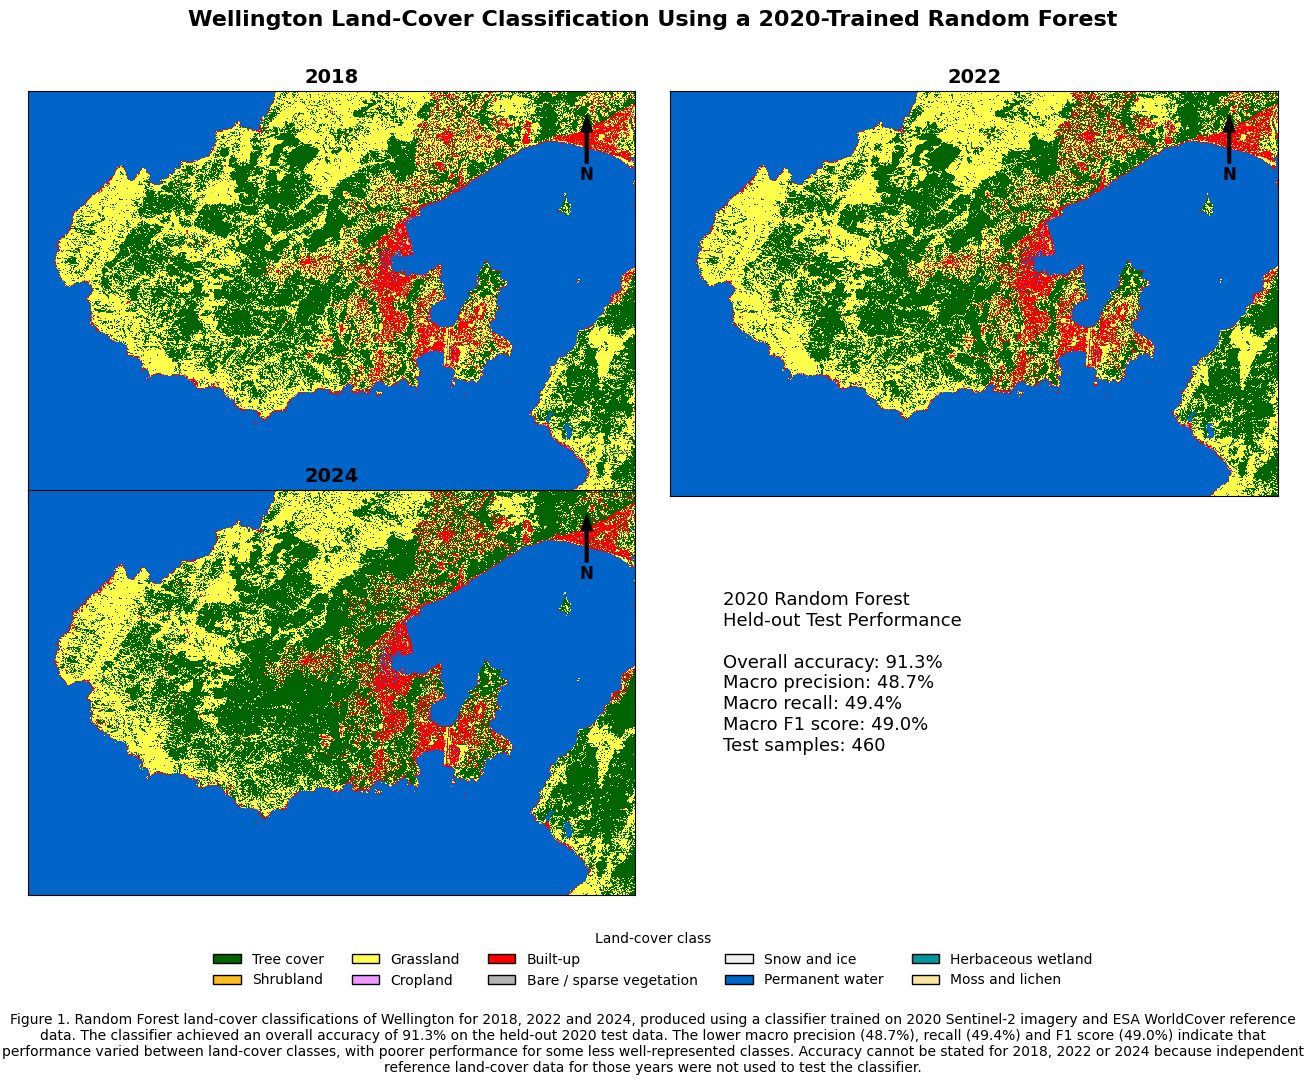

In [56]:
# Make image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

array_2018 = geemap.ee_to_numpy(
    classified_2018.toInt16(),
    region=aoi,
    scale=30
)

array_2022 = geemap.ee_to_numpy(
    classified_2022.toInt16(),
    region=aoi,
    scale=30
)

array_2024 = geemap.ee_to_numpy(
    classified_2024.toInt16(),
    region=aoi,
    scale=30
)

array_2018 = np.squeeze(array_2018).astype(float)
array_2022 = np.squeeze(array_2022).astype(float)
array_2024 = np.squeeze(array_2024).astype(float)

print(array_2018.shape)
print(array_2022.shape)
print(array_2024.shape)

# Land-cover names corresponding to the remapped ESA classes
class_names = {
    1: 'Tree cover',
    2: 'Shrubland',
    3: 'Grassland',
    4: 'Cropland',
    5: 'Built-up',
    6: 'Bare / sparse vegetation',
    7: 'Snow and ice',
    8: 'Permanent water',
    9: 'Herbaceous wetland',
    10: 'Moss and lichen'
}


# Fixed colours so that the same class has the same colour in every year.
class_colors = [
    '#006400',   # Tree cover
    '#ffbb22',   # Shrubland
    '#ffff4c',   # Grassland
    '#f096ff',   # Cropland
    '#fa0000',   # Built-up
    '#b4b4b4',   # Bare
    '#f0f0f0',   # Snow
    '#0064c8',   # Water
    '#0096a0',   # Wetland
    '#fae6a0'    # Moss
]

cmap = ListedColormap(class_colors)

norm = BoundaryNorm(
    np.arange(0.5, 11.5, 1),
    cmap.N
)

# ============================================================
# Q5 FINAL FIGURE
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 10)
)

years = [2018, 2022, 2024]

arrays = [
    array_2018,
    array_2022,
    array_2024
]


# Plot each land-cover map
for ax, year, arr in zip(
    axes.flat[:3],
    years,
    arrays
):

    ax.imshow(
        arr,
        cmap=cmap,
        norm=norm,
        interpolation='nearest'
    )

    ax.set_title(
        f'{year}',
        fontsize=14,
        fontweight='bold'
    )

    ax.set_xticks([])
    ax.set_yticks([])

    # North arrow
    ax.annotate(
        'N',
        xy=(0.92, 0.94),
        xytext=(0.92, 0.78),
        xycoords='axes fraction',
        ha='center',
        fontsize=12,
        fontweight='bold',
        arrowprops=dict(
            facecolor='black',
            width=2,
            headwidth=8
        )
    )


# Bottom-right panel = accuracy information
ax = axes.flat[3]

ax.axis('off')

performance_text = (
    '2020 Random Forest\n'
    'Held-out Test Performance\n\n'
    f'Overall accuracy: {test_accuracy*100:.1f}%\n'
    f'Macro precision: {test_precision*100:.1f}%\n'
    f'Macro recall: {test_recall*100:.1f}%\n'
    f'Macro F1 score: {test_f1*100:.1f}%\n'
    f'Test samples: {len(y_test)}'
)

ax.text(
    0.1,
    0.75,
    performance_text,
    fontsize=13,
    verticalalignment='top'
)


# Legend
legend_elements = [
    Patch(
        facecolor=class_colors[i - 1],
        edgecolor='black',
        label=class_names[i]
    )
    for i in range(1, 11)
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=5,
    bbox_to_anchor=(0.5, -0.01),
    frameon=False,
    title='Land-cover class'
)


# Overall title
fig.suptitle(
    'Wellington Land-Cover Classification Using a 2020-Trained Random Forest',
    fontsize=16,
    fontweight='bold'
)


# Caption
caption = (
    'Figure 1. Random Forest land-cover classifications of Wellington for 2018, 2022 and 2024, produced using a classifier trained on 2020 Sentinel-2 imagery and ESA WorldCover reference data. The classifier achieved an overall accuracy of 91.3% on the held-out 2020 test data. The lower macro precision (48.7%), recall (49.4%) and F1 score (49.0%) indicate that performance varied between land-cover classes, with poorer performance for some less well-represented classes. Accuracy cannot be stated for 2018, 2022 or 2024 because independent reference land-cover data for those years were not used to test the classifier.'
)

fig.text(
    0.5,
    -0.08,
    caption,
    ha='center',
    fontsize=10,
    wrap=True
)

plt.tight_layout(
    rect=[0, 0.08, 1, 0.95]
)

plt.savefig(
    'Q5_Wellington_RF.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# SVMs Applied to Satellite Data

In [ ]:
# Define and train the SVM classifier
class_property = 'Map_remapped'
svm = ee.Classifier.libsvm(kernelType='RBF', gamma=0.5, cost=10).train(
    features=train,
    classProperty=class_property,
    inputProperties=bands
)

# Classify validation and test sets
val_classified = valid.classify(svm)
test_classified = test.classify(svm)

# Evaluate test performance
test_matrix = test_classified.errorMatrix(class_property, 'classification')
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

(6) Exercise: train an SVM model using the Landcare NZ 2018 landcover database record for the region. Producing a landcover map of Great Barrier (Aotea) Island for 2018 (based off the Austral summer of 18/19 S2).

Your map should be presented at a publication quality level with all the usual map components (scale, legend, north arrow, data attribution).

You will need to provide performance statistics of the model within your figure.

*   Here you can access the landcover database: https://lris.scinfo.org.nz/layer/104400-lcdb-v50-land-cover-database-version-50-mainland-new-zealand/. You will need to explore for yourself how to extract this data and then upload it to colab, then how to plug it into the SVM algorithim. I have provided some starter code below.

An intial workflow to get the data into the state you need it in to then use it as training data might look like:
- Download the ZIP manually from their browser, having set your area of interest and used the 'Export' tool top right.
- Upload it to Colab.
- Unzip it and load with GeoPandas.
(25 pts)



In [57]:
# Code to get you started
import zipfile
import geopandas as gpd

# Upload the ZIP manually using the Colab UI
from google.colab import files
uploaded = files.upload()  # <- Expects a ZIP

# Unzip
with zipfile.ZipFile("LCDB_v5.zip", 'r') as zip_ref: #<- Check file names
    zip_ref.extractall("lcdb")

# Read shapefile
gdf = gpd.read_file("lcdb/LCDB_v5.shp") #<- Check file names
print(gdf.head())


KeyboardInterrupt: 

In [58]:
# Q6

from google.colab import files
import zipfile
import os
import glob
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    confusion_matrix
)

uploaded = files.upload()

zip_name = next(iter(uploaded.keys()))

os.makedirs("lcdb_q6", exist_ok=True)

with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall("lcdb_q6")

shapefiles = glob.glob(
    "lcdb_q6/**/*.shp",
    recursive=True
)

print("Shapefile found:")
print(shapefiles[0])

Saving lris-lcdb-v50-land-cover-database-version-50-mainland-new-zealand-SHP.zip to lris-lcdb-v50-land-cover-database-version-50-mainland-new-zealand-SHP (1).zip
Shapefile found:
lcdb_q6/lcdb-v50-land-cover-database-version-50-mainland-new-zealand.shp


In [59]:
gdf = gpd.read_file(shapefiles[0])

print("Number of polygons:", len(gdf))
print("CRS:", gdf.crs)

print("\nRelevant columns:")
print(
    gdf[
        [
            "Class_2018",
            "Name_2018"
        ]
    ].head()
)

Number of polygons: 605
CRS: EPSG:2193

Relevant columns:
   Class_2018          Name_2018
0          69  Indigenous Forest
1          10     Sand or Gravel
2          69  Indigenous Forest
3          10     Sand or Gravel
4          69  Indigenous Forest


In [60]:
# Convert to latitude/longitude for Earth Engine
gdf = gdf.to_crs("EPSG:4326")

# Remove missing classes
gdf = gdf[
    gdf["Class_2018"].notna()
].copy()

gdf["Class_2018"] = (
    gdf["Class_2018"]
    .astype(int)
)

# Show the LCDB classes present
classes_present = (
    gdf[
        [
            "Class_2018",
            "Name_2018"
        ]
    ]
    .drop_duplicates()
    .sort_values("Class_2018")
)

display(classes_present)

,Class_2018,Name_2018
40,1,Built-up Area (settlement)
154,2,Urban Parkland/Open Space
314,5,Transport Infrastructure
48,6,Surface Mine or Dump
1,10,Sand or Gravel
145,12,Landslide
167,16,Gravel or Rock
249,20,Lake or Pond
166,21,River
355,22,Estuarine Open Water


In [61]:
original_codes = sorted(
    gdf["Class_2018"]
    .unique()
)

code_to_class = {
    code: i
    for i, code in enumerate(original_codes)
}

class_to_code = {
    i: code
    for code, i in code_to_class.items()
}

name_lookup = (
    gdf[
        [
            "Class_2018",
            "Name_2018"
        ]
    ]
    .drop_duplicates("Class_2018")
    .set_index("Class_2018")["Name_2018"]
    .to_dict()
)

gdf["class_id"] = (
    gdf["Class_2018"]
    .map(code_to_class)
    .astype(int)
)

class_names_q6 = {
    class_id: name_lookup[original_code]
    for class_id, original_code
    in class_to_code.items()
}

print("SVM class mapping:")

for class_id in sorted(class_names_q6):
    print(
        class_id,
        "->",
        class_to_code[class_id],
        "->",
        class_names_q6[class_id]
    )

lcdb_for_ee = gdf[
    [
        "class_id",
        "Class_2018",
        "Name_2018",
        "geometry"
    ]
].copy()

lcdb_ee = geemap.geopandas_to_ee(
    lcdb_for_ee
)

# Study area based on downloaded polygons
aotea = lcdb_ee.geometry().bounds()

# Convert polygon labels into an image
lcdb_labels = (
    lcdb_ee
    .reduceToImage(
        properties=["class_id"],
        reducer=ee.Reducer.first()
    )
    .rename("class_id")
    .toInt()
)

print("LCDB data converted to Earth Engine.")

SVM class mapping:
0 -> 1 -> Built-up Area (settlement)
1 -> 2 -> Urban Parkland/Open Space
2 -> 5 -> Transport Infrastructure
3 -> 6 -> Surface Mine or Dump
4 -> 10 -> Sand or Gravel
5 -> 12 -> Landslide
6 -> 16 -> Gravel or Rock
7 -> 20 -> Lake or Pond
8 -> 21 -> River
9 -> 22 -> Estuarine Open Water
10 -> 33 -> Orchard, Vineyard or Other Perennial Crop
11 -> 40 -> High Producing Exotic Grassland
12 -> 41 -> Low Producing Grassland
13 -> 45 -> Herbaceous Freshwater Vegetation
14 -> 46 -> Herbaceous Saline Vegetation
15 -> 51 -> Gorse and/or Broom
16 -> 52 -> Manuka and/or Kanuka
17 -> 54 -> Broadleaved Indigenous Hardwoods
18 -> 64 -> Forest - Harvested
19 -> 69 -> Indigenous Forest
20 -> 70 -> Mangrove
21 -> 71 -> Exotic Forest
LCDB data converted to Earth Engine.


In [62]:
# Check map
Map = geemap.Map()

Map.centerObject(
    aotea,
    10
)

Map.addLayer(
    lcdb_labels.randomVisualizer(),
    {},
    "LCDB 2018"
)

Map.addLayer(
    lcdb_ee,
    {"color": "yellow"},
    "LCDB polygons",
    False
)

Map

Map(center=[-36.124020199280615, 175.2993805014166], controls=(WidgetControl(options=['position', 'transparent…

In [63]:
def mask_s2_q6(image):

    scl = image.select("SCL")

    clear = (
        scl.neq(3)          # cloud shadow
        .And(scl.neq(8))    # medium cloud
        .And(scl.neq(9))    # high cloud
        .And(scl.neq(10))   # cirrus
        .And(scl.neq(11))   # snow / ice
    )

    return (
        image
        .updateMask(clear)
        .divide(10000)
        .select(
            [
                "B2",
                "B3",
                "B4",
                "B8",
                "B11",
                "B12"
            ]
        )
    )


def make_s2_composite(start_date, end_date):

    return (
        ee.ImageCollection(
            "COPERNICUS/S2_SR_HARMONIZED"
        )
        .filterBounds(aotea)
        .filterDate(
            start_date,
            end_date
        )
        .filter(
            ee.Filter.lt(
                "CLOUDY_PIXEL_PERCENTAGE",
                30
            )
        )
        .map(mask_s2_q6)
        .median()
        .clip(aotea)
    )

# 2018 reference-period imagery for training
s2_2018 = make_s2_composite(
    "2017-12-01",
    "2018-03-01"
)

# Austral summer 2024/25 for the final 2025 map
s2_2025 = make_s2_composite(
    "2024-12-01",
    "2025-03-01"
)

print("Sentinel-2 composites created.")

def add_indices(image):

    ndvi = image.normalizedDifference(
        ["B8", "B4"]
    ).rename("NDVI")

    ndwi = image.normalizedDifference(
        ["B3", "B8"]
    ).rename("NDWI")

    ndbi = image.normalizedDifference(
        ["B11", "B8"]
    ).rename("NDBI")

    return image.addBands(
        [
            ndvi,
            ndwi,
            ndbi
        ]
    )


s2_2018 = add_indices(s2_2018)
s2_2025 = add_indices(s2_2025)

bands_q6 = [
    "B2",
    "B3",
    "B4",
    "B8",
    "B11",
    "B12",
    "NDVI",
    "NDWI",
    "NDBI"
]

Sentinel-2 composites created.


In [64]:
Map = geemap.Map()

Map.centerObject(
    aotea,
    10
)

Map.addLayer(
    s2_2018,
    {
        "bands": ["B4", "B3", "B2"],
        "min": 0,
        "max": 0.3
    },
    "2018 Sentinel-2"
)

Map.addLayer(
    s2_2025,
    {
        "bands": ["B4", "B3", "B2"],
        "min": 0,
        "max": 0.3
    },
    "2024/25 Sentinel-2",
    False
)

Map

Map(center=[-36.124020199280615, 175.2993805014166], controls=(WidgetControl(options=['position', 'transparent…

In [65]:
training_image = (
    s2_2018
    .select(bands_q6)
    .addBands(lcdb_labels)
)

samples_q6 = (
    training_image
    .stratifiedSample(
        numPoints=100,
        classBand="class_id",
        region=aotea,
        scale=20,
        seed=2,
        geometries=True
    )
)

print(
    "Total samples:",
    samples_q6.size().getInfo()
)

print(
    "\nSamples per class:"
)

print(
    samples_q6
    .aggregate_histogram("class_id")
    .getInfo()
)

Total samples: 2057

Samples per class:
{'0': 100, '1': 100, '10': 100, '11': 100, '12': 100, '13': 100, '14': 100, '15': 100, '16': 100, '17': 100, '18': 100, '19': 100, '2': 100, '20': 100, '21': 100, '3': 55, '4': 100, '5': 65, '6': 100, '7': 37, '8': 100, '9': 100}


In [66]:
samples_q6 = samples_q6.randomColumn(
    "random",
    seed=2
)

train_q6 = samples_q6.filter(
    ee.Filter.lt(
        "random",
        0.7
    )
)

valid_q6 = samples_q6.filter(
    ee.Filter.And(
        ee.Filter.gte(
            "random",
            0.7
        ),
        ee.Filter.lt(
            "random",
            0.9
        )
    )
)

test_q6 = samples_q6.filter(
    ee.Filter.gte(
        "random",
        0.9
    )
)

print(
    "Training:",
    train_q6.size().getInfo()
)

print(
    "Validation:",
    valid_q6.size().getInfo()
)

print(
    "Test:",
    test_q6.size().getInfo()
)

Training: 1443
Validation: 412
Test: 202


In [67]:
results = []

cost_values = [
    1,
    10,
    100
]

gamma_values = [
    0.1,
    0.5,
    1.0
]


for cost_value in cost_values:

    for gamma_value in gamma_values:

        model = (
            ee.Classifier.libsvm(
                kernelType="RBF",
                cost=cost_value,
                gamma=gamma_value
            )
            .train(
                features=train_q6,
                classProperty="class_id",
                inputProperties=bands_q6
            )
        )

        predicted = valid_q6.classify(
            model,
            "predicted"
        )

        y_true = (
            predicted
            .aggregate_array("class_id")
            .getInfo()
        )

        y_pred = (
            predicted
            .aggregate_array("predicted")
            .getInfo()
        )

        accuracy = accuracy_score(
            y_true,
            y_pred
        )

        results.append(
            {
                "cost": cost_value,
                "gamma": gamma_value,
                "validation_accuracy":
                    accuracy
            }
        )


results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "validation_accuracy",
        ascending=False
    )
)

,cost,gamma,validation_accuracy
8,100,1.0,0.485437
7,100,0.5,0.480583
5,10,1.0,0.446602
6,100,0.1,0.432039
4,10,0.5,0.427184
2,1,1.0,0.359223
3,10,0.1,0.354369
1,1,0.5,0.327670
0,1,0.1,0.150485


In [68]:
best_row = results_df.loc[
    results_df[
        "validation_accuracy"
    ].idxmax()
]

best_cost = float(
    best_row["cost"]
)

best_gamma = float(
    best_row["gamma"]
)

best_validation_accuracy = float(
    best_row["validation_accuracy"]
)

print(
    "Best cost:",
    best_cost
)

print(
    "Best gamma:",
    best_gamma
)

print(
    "Best validation accuracy:",
    round(
        best_validation_accuracy,
        3
    )
)

Best cost: 100.0
Best gamma: 1.0
Best validation accuracy: 0.485


In [69]:
final_training_q6 = (
    train_q6.merge(
        valid_q6
    )
)

svm_final_q6 = (
    ee.Classifier.libsvm(
        kernelType="RBF",
        cost=best_cost,
        gamma=best_gamma
    )
    .train(
        features=final_training_q6,
        classProperty="class_id",
        inputProperties=bands_q6
    )
)

print("Final SVM trained.")

tested_q6 = test_q6.classify(
    svm_final_q6,
    "predicted"
)

q6_true = (
    tested_q6
    .aggregate_array("class_id")
    .getInfo()
)

q6_pred = (
    tested_q6
    .aggregate_array("predicted")
    .getInfo()
)


q6_accuracy = accuracy_score(
    q6_true,
    q6_pred
)

q6_precision = precision_score(
    q6_true,
    q6_pred,
    average="macro",
    zero_division=0
)

q6_recall = recall_score(
    q6_true,
    q6_pred,
    average="macro",
    zero_division=0
)

q6_f1 = f1_score(
    q6_true,
    q6_pred,
    average="macro",
    zero_division=0
)

q6_kappa = cohen_kappa_score(
    q6_true,
    q6_pred
)


print(
    f"Test Accuracy:  "
    f"{q6_accuracy:.3f}"
)

print(
    f"Test Precision: "
    f"{q6_precision:.3f}"
)

print(
    f"Test Recall:    "
    f"{q6_recall:.3f}"
)

print(
    f"Test F1 Score:  "
    f"{q6_f1:.3f}"
)

print(
    f"Cohen's Kappa:  "
    f"{q6_kappa:.3f}"
)

Final SVM trained.
Test Accuracy:  0.495
Test Precision: 0.438
Test Recall:    0.464
Test F1 Score:  0.414
Cohen's Kappa:  0.468


In [70]:
# Make map
classified_q6 = (
    s2_2025
    .select(bands_q6)
    .classify(svm_final_q6)
    .clip(aotea)
)

print(
    "2025 classification created."
)

Map = geemap.Map()

Map.centerObject(
    aotea,
    10
)

Map.addLayer(
    classified_q6.randomVisualizer(),
    {},
    "2025 SVM classification"
)

Map.addLayer(
    s2_2025,
    {
        "bands": [
            "B4",
            "B3",
            "B2"
        ],
        "min": 0,
        "max": 0.3
    },
    "Sentinel-2 RGB",
    False
)

Map

2025 classification created.


Map(center=[-36.124020199280615, 175.2993805014166], controls=(WidgetControl(options=['position', 'transparent…